# Data Loading Pipeline and EDA notebook

The first thing that I did was setup the variables and project structure for this assingment. I then went and used the download.py to get all of the WAV files inside of the data folder under SER project.

So initial steps: Go to the download_data.py and run the program, then go to Minilearn and run initialDataPipeline.py to create the CSV.

In [275]:
#Imports
from pathlib import Path   
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
# Audio
import librosa
import librosa.display
from minilearn.InitialDataPipeline import build_metadata


In [276]:
PROJECT_ROOT = Path("SER_Project")
DATA_DIR = PROJECT_ROOT / "data"

wav_files = sorted(DATA_DIR.rglob("*.wav"))

print(f"Number of WAV files found: {len(wav_files)}")
print(wav_files[:5])

Number of WAV files found: 2452
[WindowsPath('SER_Project/data/Actor_01/03-01-01-01-01-01-01.wav'), WindowsPath('SER_Project/data/Actor_01/03-01-01-01-01-02-01.wav'), WindowsPath('SER_Project/data/Actor_01/03-01-01-01-02-01-01.wav'), WindowsPath('SER_Project/data/Actor_01/03-01-01-01-02-02-01.wav'), WindowsPath('SER_Project/data/Actor_01/03-01-02-01-01-01-01.wav')]


So to be able to create a dataframe/table from the audio files I will have to split them up into there identifiers and create maps to be able to figure out the meaning of each. 

What I mean by this is that each .wav files has there own identifiers for different properties split with a dash (-). Then inside each propertie is a number that identifies to a different property. For example we could have this string: 
03-01-05-01-02-01-12.wav. The 3 is the modality, but the three means the modality is audio-only. Below I setup a map for each so I know what the values are to append. We dont need one for actor because its already an identifer by its number and cna find gender by doing a quick math operation.

In [277]:
modality_values = {
    "01":"full_AV",
    "02":"video-only",
    "03":"audio-only",
}
vocal_channel_values = {
    "01":"speech",
    "02":"song",
}
emotion_values = {
    "01":"neutral",
    "02":"calm",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fearful",
    "07":"disgust",
    "08":"surprised",
}
intensity_values = {
    "01":"normal",
    "02":"strong",
}
statement_values = {
    "01":"Kids are talking by the door",
    "02":"Dogs are sitting by the door",
}
repetition_values = {
    "01":"1st",
    "02":"2nd",
}


Below is where I put the entire thing together to create the dataframe. First I create the empty rows where the data frame info will be stored before becoming one. I use a for loop to go through every single wav file and classify it by the identifiers found in the file name. Using the map to get the understanding and keeping the code from the file.

In [278]:
rows = []

for file in wav_files:
    #splitting using the identifier like you would in a CSV
    parts = file.stem.split("-")

    #Checking to make sure it has all parts
    if len(parts) != 7:
        print("this is invalid not using it")
        continue

    actor = int(parts[6])
    gender = ""
    if (actor % 2 == 1) :
        gender = "male"
    else:
        gender = "female"

    rows.append({
        "filename" : file.name,
        "modality_number" : parts[0],
        "modality": modality_values.get(parts[0]),
        "vocal_channel_number" : parts[1],
        "vocal_channel": vocal_channel_values.get(parts[1]),
        "emotion_code" : parts[2],
        "emotion": emotion_values.get(parts[2]),
        "intensity_number" : parts[3],
        "intensity": intensity_values.get(parts[3]),
        "statement_number" : parts[4],
        "statement": statement_values.get(parts[4]),
        "repeition_number" : parts[5],
        "repetition": repetition_values.get(parts[5]),
        "actor": actor,
        "gender": gender,
    })

metadata_table = pd.DataFrame(rows)

metadata_table.head()



,filename,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,statement_number,statement,repeition_number,repetition,actor,gender
0,03-01-01-01-01-01-01.wav,03,audio-only,01,speech,01,neutral,01,normal,01,Kids are talking by the door,01,1st,1,male
1,03-01-01-01-01-02-01.wav,03,audio-only,01,speech,01,neutral,01,normal,01,Kids are talking by the door,02,2nd,1,male
2,03-01-01-01-02-01-01.wav,03,audio-only,01,speech,01,neutral,01,normal,02,Dogs are sitting by the door,01,1st,1,male
3,03-01-01-01-02-02-01.wav,03,audio-only,01,speech,01,neutral,01,normal,02,Dogs are sitting by the door,02,2nd,1,male
4,03-01-02-01-01-01-01.wav,03,audio-only,01,speech,02,calm,01,normal,01,Kids are talking by the door,01,1st,1,male


Just making sure that all of the data points and columns that are supposed to be there are there

In [279]:
print("Shape:", metadata_table.shape)
print("Columns:")
print(metadata_table.columns.tolist())

Shape: (2452, 15)
Columns:
['filename', 'modality_number', 'modality', 'vocal_channel_number', 'vocal_channel', 'emotion_code', 'emotion', 'intensity_number', 'intensity', 'statement_number', 'statement', 'repeition_number', 'repetition', 'actor', 'gender']


Now below I am going to be going one by one to show you some different plots of the data and emotions etc. These next graphs will just be distributions of each of the 7 properties. However, I am going to leave out the modality because it is only allowed to be voice only so that chart would be nothing. The actor distribution also makes not a lot of sense to put up because the 18th actor missing half of his lines were in the description and the rest of that graph was uniform.

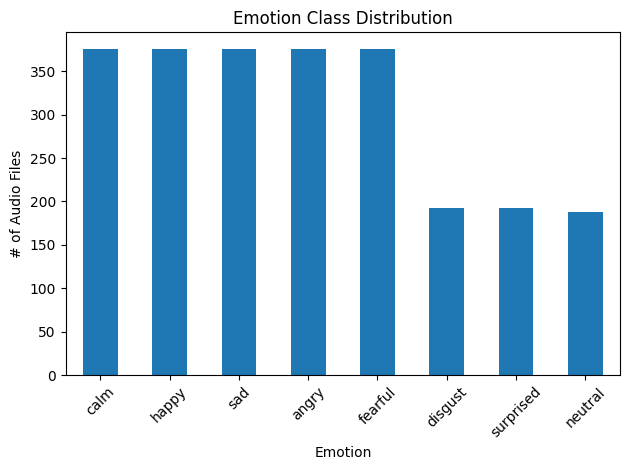

In [280]:
emotion_count = metadata_table["emotion"].value_counts()

plt.Figure(figsize=(6,4))
emotion_count.plot(kind="bar")
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("# of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


For the emotions graph you can see the distribution across all of the audio files. There seems to be around 375 audio files for calm, happy, sad, angry, and fearful. However disgust, surprised and nuetral have around the same number of audio files at around 175 each. I imagine later on with fewer data points for disgust, surprised, and nuetral that it could be harder to classify those emotions correctly.

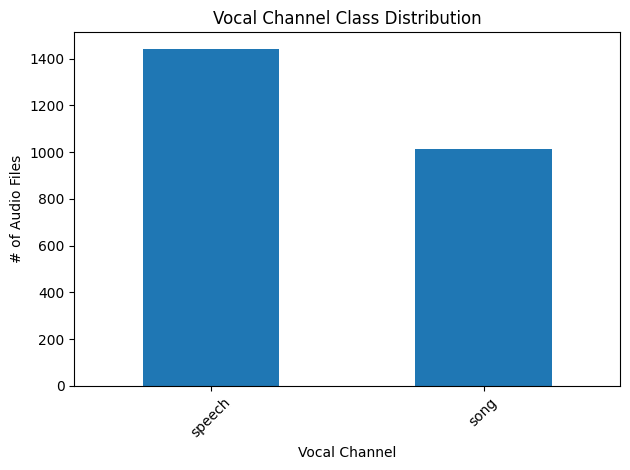

In [281]:
vocal_channel_count = metadata_table["vocal_channel"].value_counts()

plt.Figure(figsize=(6,4))
vocal_channel_count.plot(kind="bar")
plt.title("Vocal Channel Class Distribution")
plt.xlabel("Vocal Channel")
plt.ylabel("# of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

For the vocal channel distribution there is a lot more speech then there is song. With speech being comprised of around 1420 audio files and song only being around 1050. I imagine that song might be harder to classify emotions in due to the far higher speech make up.

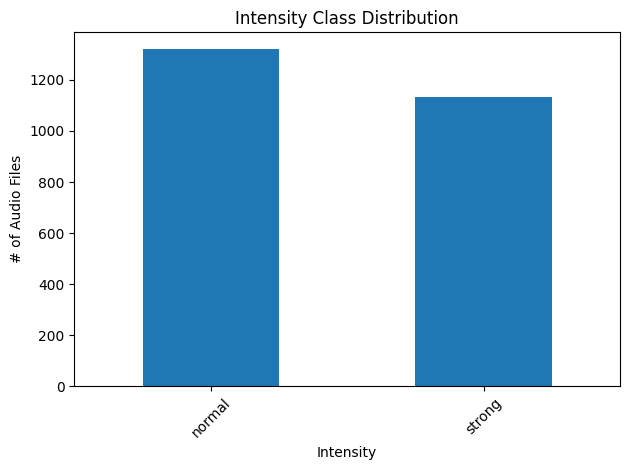

In [282]:
intensity_values_count = metadata_table["intensity"].value_counts()

plt.Figure(figsize=(6,4))
intensity_values_count.plot(kind="bar")
plt.title("Intensity Class Distribution")
plt.xlabel("Intensity")
plt.ylabel("# of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

For the intensity and most of the graphs that are distributed across two different classes we have a skew to one compared to the other. Just like other graphs there isnt a clear 50/50 split here. Normal intensity appears to be made up around 1350 audio files, while strong appears to made up of 1100. 

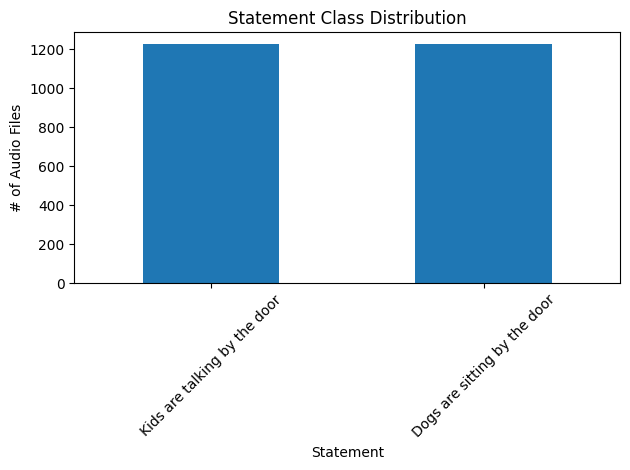

In [283]:
statement_values_count = metadata_table["statement"].value_counts()

plt.Figure(figsize=(6,4))
statement_values_count.plot(kind="bar")
plt.title("Statement Class Distribution")
plt.xlabel("Statement")
plt.ylabel("# of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph for the properties split up into two seems to be very 50/50 when it comes to distribution. The two statements appear to have the same or close to the same amount of audio files in each

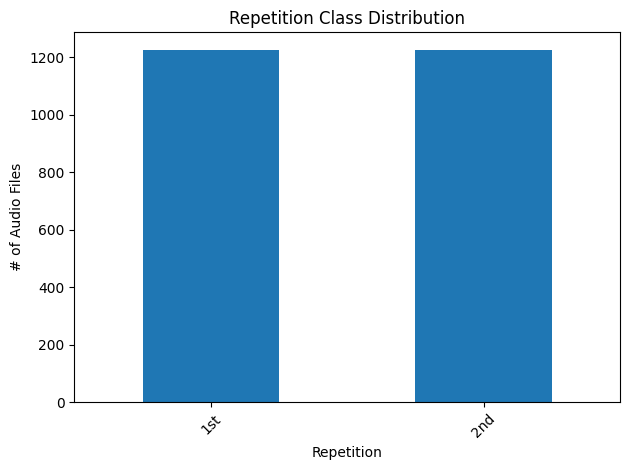

In [284]:
repetition_values_count = metadata_table["repetition"].value_counts()

plt.Figure(figsize=(6,4))
repetition_values_count.plot(kind="bar")
plt.title("Repetition Class Distribution")
plt.xlabel("Repetition")
plt.ylabel("# of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Just like the statement graph the repition seems to be even between the first and second classes. They both appear to have around 1225 audio files in each

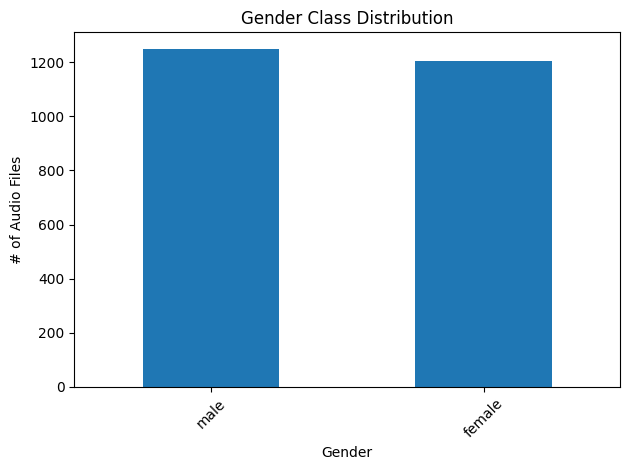

In [285]:
repetition_values_count = metadata_table["gender"].value_counts()

plt.Figure(figsize=(6,4))
repetition_values_count.plot(kind="bar")
plt.title("Gender Class Distribution")
plt.xlabel("Gender")
plt.ylabel("# of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The gender graphs appear to be very similar with maybe give or take 50 from each class. I imagine the gender distribution will be easy to distribute between the two different classes 

I realized this after the fact but we need a way to save this to a file that makes sense for us to be able to use in future journals. Therefore we should save it into a csv to make a dataframe for feature extraction. I have created a new data pipeline .py to be able to accomplish this. you should run this command to create the CSV from whihc we will be pulling from later. 

In [288]:
from minilearn.InitialDataPipeline import build_metadata

metadata_table = build_metadata()




Saved metadata table to: SER_Project\data\processed\ravdess_metadata.csv
Shape: (2452, 15)
                   filename modality_number    modality vocal_channel_number  \
0  03-01-01-01-01-01-01.wav              03  audio-only                   01   
1  03-01-01-01-01-02-01.wav              03  audio-only                   01   
2  03-01-01-01-02-01-01.wav              03  audio-only                   01   
3  03-01-01-01-02-02-01.wav              03  audio-only                   01   
4  03-01-02-01-01-01-01.wav              03  audio-only                   01   

  vocal_channel emotion_code  emotion intensity_number intensity  \
0        speech           01  neutral               01    normal   
1        speech           01  neutral               01    normal   
2        speech           01  neutral               01    normal   
3        speech           01  neutral               01    normal   
4        speech           02     calm               01    normal   

  statement_number 